##### 1. Import Libraries

Loads all required libraries for the workflow. pandas and numpy handle data manipulation, sklearn modules are used for splitting the dataset, building the decision tree, and evaluating performance, and matplotlib is used to generate visualizations. This setup prepares the environment for processing the mushroom dataset and building the classification model.

In [26]:
# Core data handling
import pandas as pd
import numpy as np

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report

# Visualization
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


##### 2. Data Loading

Loads the mushroom dataset from the Excel file into a pandas DataFrame. This creates a structured table (df) with 8124 rows and 23 categorical features, which will be used for all further analysis and modeling.

In [27]:
# Read the Mushroom dataset Excel file into a pandas DataFrame
df = pd.read_excel("mushrooms.xlsx")

##### 3. Initial Data Inspection

Performs initial data inspection to understand the dataset. Confirms the size (8124 × 23), previews sample rows, and checks that all variables are categorical (object type). It also verifies no missing or duplicate rows, while identifying unique category values that will be important for feature analysis and encoding.

In [28]:
# Shape of the datset
df.shape

(8124, 23)

In [29]:
# View sample records
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [30]:
# Structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [31]:
# Statistical summary (mostly useful for encoded data later)
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [32]:
# Missing values check
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [33]:
# Check unique values per column (important for categorical data understanding)
for col in df.columns:
        print(f"{col}: {df[col].unique()}")

class: ['p' 'e']
cap-shape: ['x' 'b' 's' 'f' 'k' 'c']
cap-surface: ['s' 'y' 'f' 'g']
cap-color: ['n' 'y' 'w' 'g' 'e' 'p' 'b' 'u' 'c' 'r']
bruises: ['t' 'f']
odor: ['p' 'a' 'l' 'n' 'f' 'c' 'y' 's' 'm']
gill-attachment: ['f' 'a']
gill-spacing: ['c' 'w']
gill-size: ['n' 'b']
gill-color: ['k' 'n' 'g' 'p' 'w' 'h' 'u' 'e' 'b' 'r' 'y' 'o']
stalk-shape: ['e' 't']
stalk-root: ['e' 'c' 'b' 'r' '?']
stalk-surface-above-ring: ['s' 'f' 'k' 'y']
stalk-surface-below-ring: ['s' 'f' 'y' 'k']
stalk-color-above-ring: ['w' 'g' 'p' 'n' 'b' 'e' 'o' 'c' 'y']
stalk-color-below-ring: ['w' 'p' 'g' 'b' 'n' 'e' 'y' 'o' 'c']
veil-type: ['p']
veil-color: ['w' 'n' 'o' 'y']
ring-number: ['o' 't' 'n']
ring-type: ['p' 'e' 'l' 'f' 'n']
spore-print-color: ['k' 'n' 'u' 'h' 'w' 'r' 'o' 'y' 'b']
population: ['s' 'n' 'a' 'v' 'y' 'c']
habitat: ['u' 'g' 'm' 'd' 'p' 'w' 'l']


In [34]:
# Duplicates rows
print(df.duplicated().sum())

0


##### 4. Data Cleaning and Preprocessing

Removes the `veil-type` column because it has only one value and doesn’t help in classification. Also replaces `?` in `stalk-root` with `"missing"` so that missing values are clearly handled and can be treated as a separate category during encoding.

In [35]:
# Remove 'veil-type' column because it has only 1 unique value (no information gain)
df = df.drop(columns=["veil-type"])

# Replace '?' values with "missing" (these represent missing values in 'stalk-root')
df = df.replace('?', 'missing')

##### 5. Exploratory Analysis 

##### 5.1 Odor vs Class Relationship

Analyzes relationships between features and the target variable. The odor cross-tab shows how certain odors strongly indicate edible or poisonous mushrooms.

In [36]:
# Create a contingency table to see relationship between odor and class
# This helps identify if odor is a strong predictor of poisonous vs edible
odor_table = pd.crosstab(df['class'], df['odor'])

print(odor_table)

odor     a    c     f    l   m     n    p    s    y
class                                              
e      400    0     0  400   0  3408    0    0    0
p        0  192  2160    0  36   120  256  576  576


##### 5.2 Perfect Split Analysis

The perfect split analysis counts how often a feature cleanly separates classes (zero overlap), which helps in identifying the most informative variables. The bar chart visualizes which features (like odor) are strongest predictors for classification.

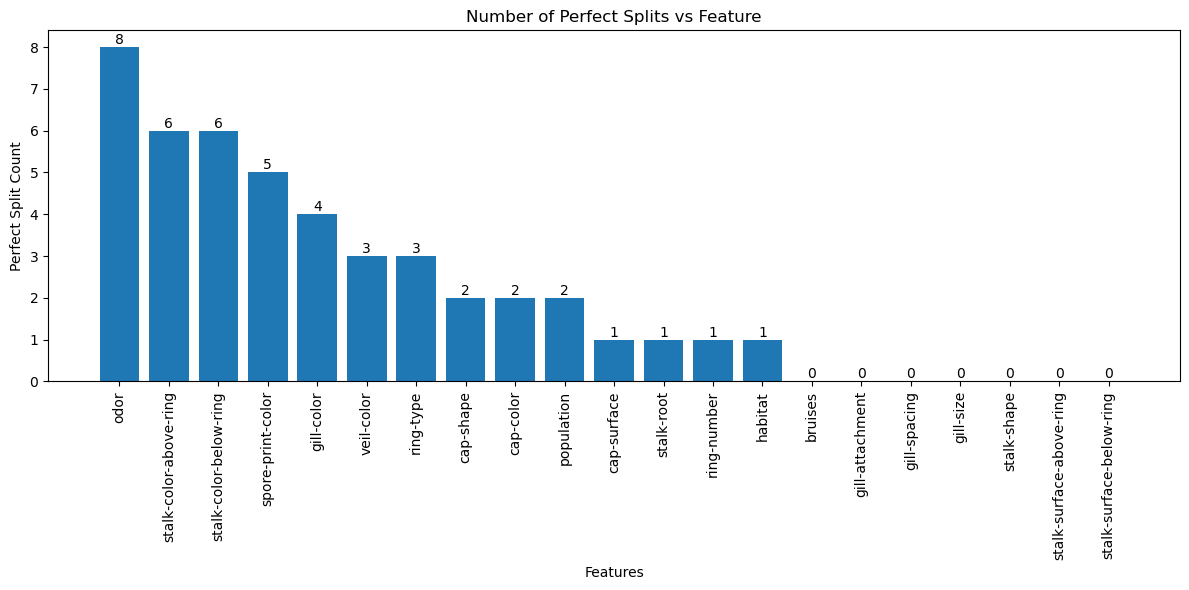

In [ ]:
# Measures how well each feature separates classes

# Dictionary to store number of "perfect splits" for each feature
perfect_splits = {}

# Loop through each feature (excluding target column)
for col in df.columns[1:]:
    
    # Create contingency table between class and feature
    t = pd.crosstab(df['class'], df[col])
    
    # Count how many cells are zero
    # A zero means that category perfectly separates a class
    perfect_splits[col] = (t == 0).sum().sum()

# Sort features by highest number of perfect splits
perfect_splits = dict(sorted(perfect_splits.items(), key=lambda x: x[1], reverse=True))

# Plot bar chart to visualize which features are most informative
plt.figure(figsize=(12,6))
bars = plt.bar(perfect_splits.keys(), perfect_splits.values())
plt.xticks(rotation=90)
plt.title("Number of Perfect Splits vs Feature")
plt.xlabel("Features")
plt.ylabel("Perfect Split Count")

# Add values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # x position
        height,                             # y position
        str(int(height)),                   # label
        ha='center', va='bottom'
    )

plt.tight_layout()
plt.show()

##### 6. Feature Engineering (Encoding)

Prepares data for modeling by separating features (X) and target (y). Since all variables are categorical, one-hot encoding is applied to convert them into numeric format. It allows the decision tree model to process the data correctly.

In [38]:
# Separate features (X) and target (y)
X = df.drop(columns=["class"])
y = df["class"]

# Convert categorical variables into numerical format using one-hot encoding
# This is required because sklearn models cannot handle text categories directly
X_encoded = pd.get_dummies(X)

##### 7. Train-Test Split

Splits the dataset into training (80%) and testing (20%) sets. The model learns patterns from the training data and is evaluated on unseen test data to check performance. Consistent outcomes between runs are guaranteed by `random_state=12345`.

In [39]:
# Split dataset into training (80%) and testing (20%)
# random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=12345
)

##### 8. Model Building (Decision Tree)

Builds the decision tree model to classify mushrooms as edible or poisonous. A higher weight is assigned to poisonous (`p`) cases to reduce the risk of misclassification. The model learns decision rules (e.g., based on odor and other features) from the training data using the Gini criterion.

In [40]:
# Assign higher penalty to poisonous misclassification
class_weights = {'e': 1, 'p': 10}

# Create decision tree classifier
tree = DecisionTreeClassifier(
    criterion='gini',          # Splitting criterion (same as default in rpart)
    class_weight=class_weights,  # Apply penalty for poisonous misclassification
    random_state=12345
)

# Train the model using training data
tree.fit(X_train, y_train)

print('\nDecision tree model trained.')


Decision tree model trained.


##### 9. Tree Visualization

Visualizes the trained decision tree to show how features (e.g., odor, gill-size) are used to split the data and classify mushrooms. This helps interpret the model by revealing the decision rules leading to edible or poisonous outcomes.

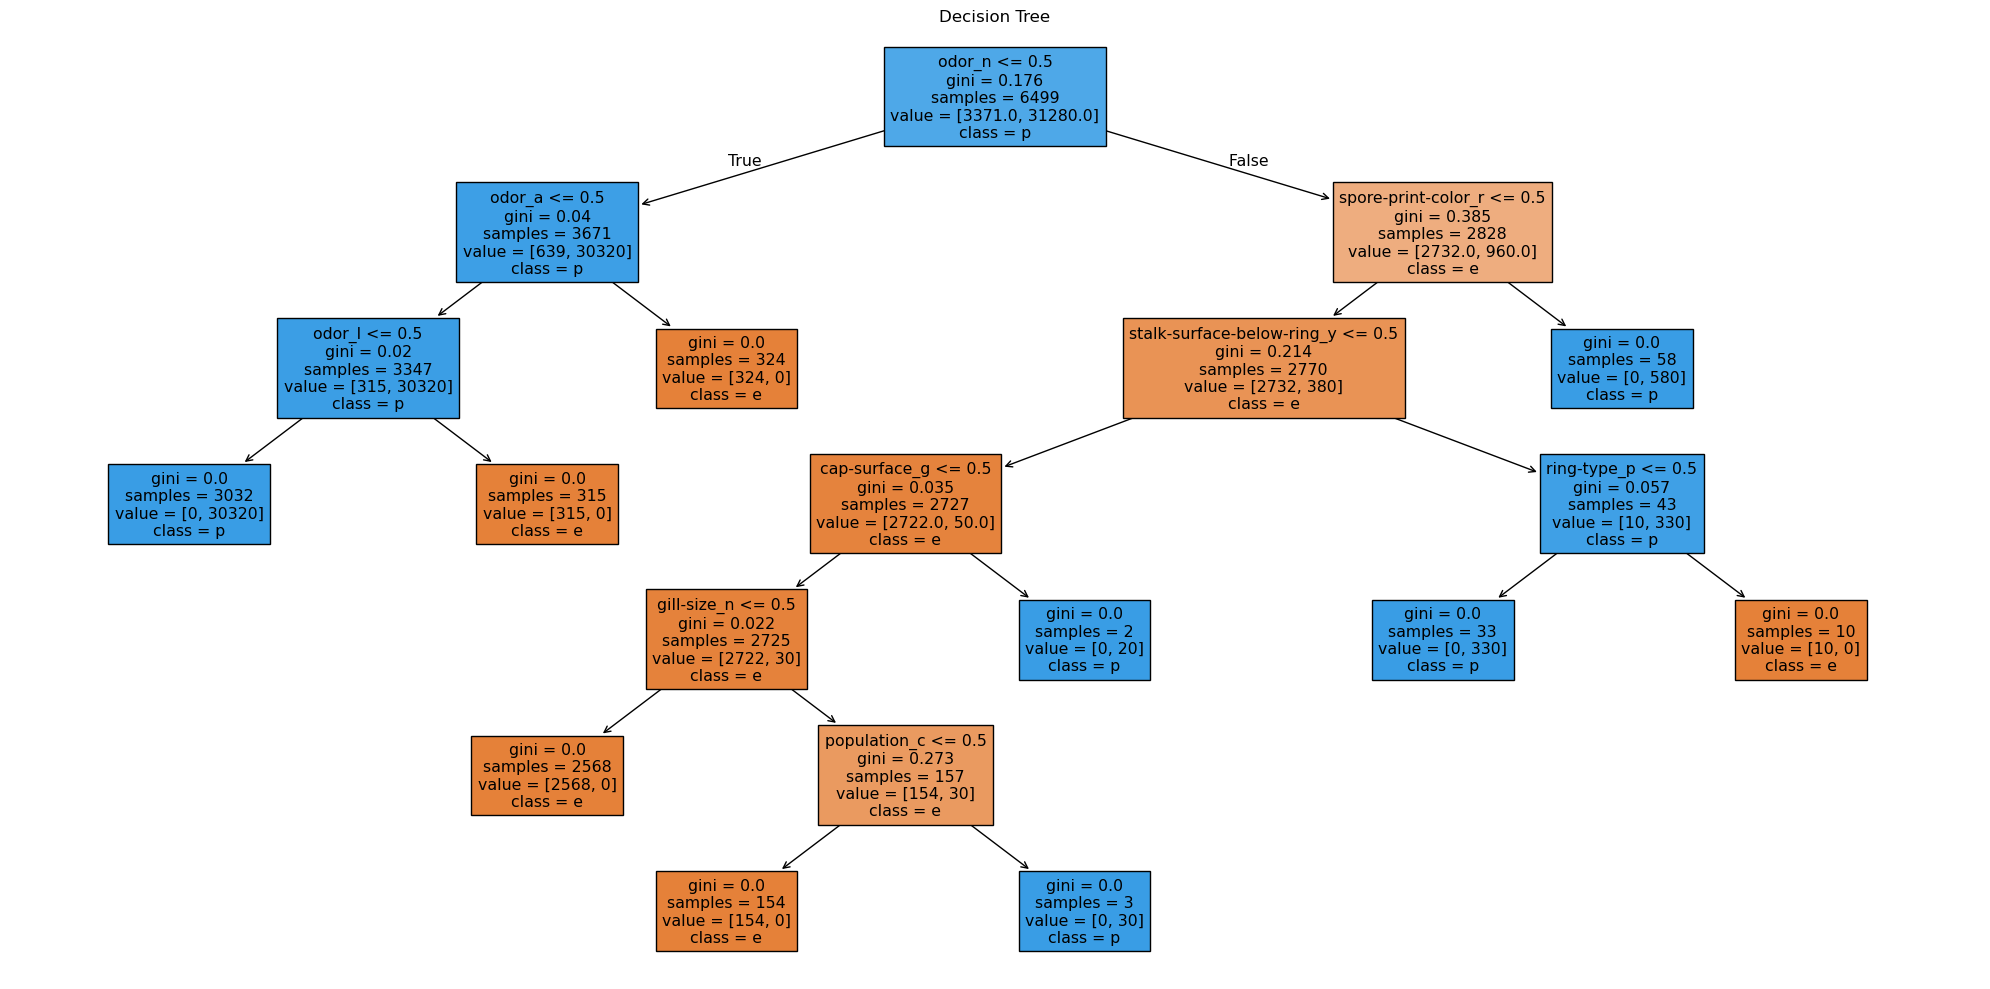

In [41]:
# Plot the decision tree structure
plt.figure(figsize=(20,10))

plot_tree(
    tree,
    filled=True,                     # Color nodes by class
    feature_names=X_encoded.columns, # Show feature names
    class_names=tree.classes_        # Show class labels
)

plt.title('Decision Tree')
plt.tight_layout()
plt.show()

##### 10. Pruning (Model Optimization)

Optimizes the decision tree using cost-complexity pruning. Multiple trees are trained with different `alpha` values, and their performance is evaluated on test data. The plot shows how pruning affects accuracy, and the best tree is selected based on highest test accuracy (here, optimal alpha = 0.0).

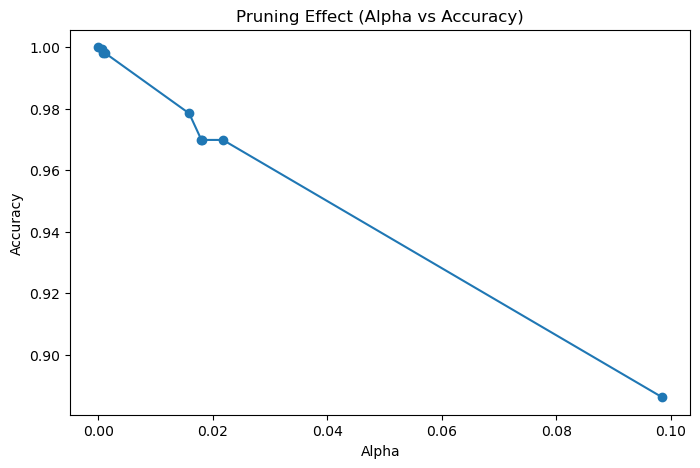


Best alpha: 0.0


In [42]:
# Get pruning path
path = tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

trees = []
scores = []

# Train multiple trees with different pruning levels
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=12345, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    
    trees.append(clf)
    scores.append(clf.score(X_test, y_test))

# Plot alpha vs accuracy
plt.figure(figsize=(8,5))
plt.plot(ccp_alphas, scores, marker='o')
plt.title("Pruning Effect (Alpha vs Accuracy)")
plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.show()

# Select best tree
best_tree = trees[np.argmax(scores)]

print("\nBest alpha:", ccp_alphas[np.argmax(scores)])

##### 11. Model Evaluation

Uses test data to assess the finished model. A confusion matrix and classification report are used to compare predictions with actual values. The model correctly distinguishes between edible and deadly mushrooms on the test set, according to the results, which indicate perfect classification (no misclassifications).


Confusion Matrix:
 [[837   0]
 [  0 788]]


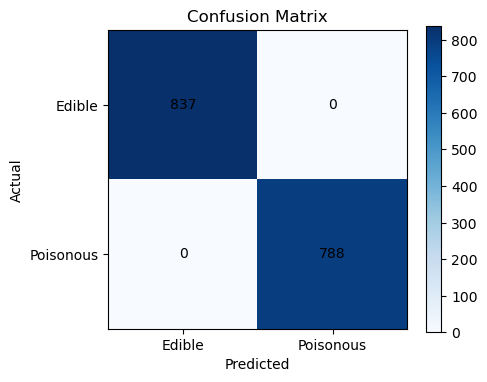


Classification Report:

              precision    recall  f1-score   support

           e       1.00      1.00      1.00       837
           p       1.00      1.00      1.00       788

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [45]:
# Predictions
y_pred = best_tree.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)

# Visualization
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ['Edible', 'Poisonous'])
plt.yticks([0,1], ['Edible', 'Poisonous'])
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Annotate values
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))